# Rainfall and ET Diagnostic for Day Selection

This notebook plots rainfall and evapotranspiration-related CLM outputs so you can pick representative days for figures.

## Data assumptions used here
- `WY2022.txt` is 1D CLM meteorological forcing with 8 columns.
- Column 3 (`APCP`) is precipitation rate in `mm/s` (ParFlow docs).
- `sc2d_6.out.clm_output.*.C.pfb` is CLM single-file output.
- We use CLM layer index `4` as `qflx_evap_tot` and index `8` as `qflx_tran_veg` (ParFlow CLM single-file order).

> Note: ET here is sampled from available CLM output timesteps and converted to `mm/day` equivalent (`mm/s * 86400`).
> It is very useful for selecting representative days, but it is not a strict daily-integrated ET budget.


In [296]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import numpy as np

try:
    from parflow.tools.io import read_pfb
except Exception as exc:
    raise RuntimeError(
        "Failed to import parflow.tools.io.read_pfb. Run in the project .venv (uv sync --extra examples)."
    ) from exc

plt.style.use("seaborn-v0_8-whitegrid")

# Register Arial from Windows fonts (WSL path) when available.
for font_path in (
    "/mnt/c/Windows/Fonts/arial.ttf",
    "/mnt/c/Windows/Fonts/arialbd.ttf",
    "/mnt/c/Windows/Fonts/ariali.ttf",
    "/mnt/c/Windows/Fonts/arialbi.ttf",
):
    path_obj = Path(font_path)
    if path_obj.exists():
        fm.fontManager.addfont(str(path_obj))

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]

np.set_printoptions(precision=4, suppress=True)


In [297]:
# Resolve project paths (works when notebook is launched from repo root or examples/)
here = Path.cwd().resolve()
if (here / "parflow_models").exists():
    project_root = here
elif (here.parent / "parflow_models").exists():
    project_root = here.parent
else:
    raise FileNotFoundError("Cannot find parflow_models from current working directory.")

parflow_dir = project_root / "parflow_models"
print("project_root =", project_root)
print("parflow_dir   =", parflow_dir)


project_root = /home/luffy/deepertv1
parflow_dir   = /home/luffy/deepertv1/parflow_models


In [298]:
# 1) Rainfall from WY2022.txt
met = np.loadtxt(parflow_dir / "WY2022.txt")
if met.ndim != 2 or met.shape[1] != 8:
    raise ValueError(f"Expected WY2022.txt shape (N, 8), got {met.shape}")

# ParFlow CLM forcing order (1D text): DSWR, DLWR, APCP, Temp, UGRD, VGRD, Press, SPFH
rain_mm_s = met[:, 2]
n_hours = rain_mm_s.size
if n_hours % 24 != 0:
    raise ValueError(f"Expected hourly forcing length divisible by 24, got {n_hours}")

n_days = n_hours // 24
rain_mm_h = rain_mm_s * 3600.0
rain_mm_day = rain_mm_h.reshape(n_days, 24).sum(axis=1)
days = np.arange(1, n_days + 1)

print("forcing shape:", met.shape)
print("days:", n_days, "rain daily sum [mm/day] min/max =", float(rain_mm_day.min()), float(rain_mm_day.max()))


forcing shape: (8760, 8)
days: 365 rain daily sum [mm/day] min/max = 0.0 28.41469979286194


In [299]:
# 2) ET-related flux from CLM single-file outputs
# CLM output layer mapping used here (0-based):
# 4 -> qflx_evap_tot [mm/s]
# 8 -> qflx_tran_veg [mm/s]

pat = re.compile(r"sc2d_6\.out\.clm_output\.(\d+)\.C\.pfb$")
pairs = []
for p in sorted(parflow_dir.glob("sc2d_6.out.clm_output.*.C.pfb")):
    m = pat.match(p.name)
    if m:
        pairs.append((int(m.group(1)), p))

if not pairs:
    raise FileNotFoundError("No CLM single-file outputs found: sc2d_6.out.clm_output.*.C.pfb")

steps = []
evap_tot_mm_s = []
tran_veg_mm_s = []

for step, path in pairs:
    arr = np.asarray(read_pfb(str(path)), dtype=float)
    if arr.ndim != 3 or arr.shape[0] < 9:
        raise ValueError(f"Unexpected CLM single-file shape at {path.name}: {arr.shape}")
    evap_tot_mm_s.append(float(np.nanmean(arr[4, :, :])))
    tran_veg_mm_s.append(float(np.nanmean(arr[8, :, :])))
    steps.append(step)

steps = np.asarray(steps, dtype=int)
evap_tot_mm_s = np.asarray(evap_tot_mm_s, dtype=float)
tran_veg_mm_s = np.asarray(tran_veg_mm_s, dtype=float)

# map CLM step index to day index (step 1 -> day 1, step 25 -> day 2, ...)
day_from_step = ((steps - 1) // 24) + 1

evap_tot_mm_day_equiv = evap_tot_mm_s * 86400.0
tran_veg_mm_day_equiv = tran_veg_mm_s * 86400.0

print("CLM files:", len(pairs))
print("step range:", int(steps.min()), "to", int(steps.max()))
print("day range from CLM outputs:", int(day_from_step.min()), "to", int(day_from_step.max()))
print("qflx_evap_tot [mm/day equiv] min/max =", float(np.nanmin(evap_tot_mm_day_equiv)), float(np.nanmax(evap_tot_mm_day_equiv)))


CLM files: 365
step range: 1 to 8737
day range from CLM outputs: 1 to 365
qflx_evap_tot [mm/day equiv] min/max = -0.6494218475535568 3.8568133256544503


In [300]:
# 3) Align ET snapshots onto full day axis [1..365]
evap_day = np.full(n_days, np.nan, dtype=float)
tran_day = np.full(n_days, np.nan, dtype=float)
for d, e, t in zip(day_from_step, evap_tot_mm_day_equiv, tran_veg_mm_day_equiv):
    if 1 <= d <= n_days:
        evap_day[d - 1] = e
        tran_day[d - 1] = t


def moving_avg(x: np.ndarray, w: int) -> np.ndarray:
    if w <= 1:
        return x.copy()
    kernel = np.ones(w, dtype=float) / float(w)
    return np.convolve(x, kernel, mode="same")


rain_7d = moving_avg(rain_mm_day, 7)
evap_7d = moving_avg(np.nan_to_num(evap_day, nan=0.0), 7)
tran_7d = moving_avg(np.nan_to_num(tran_day, nan=0.0), 7)

print("ET coverage (non-NaN days):", int(np.isfinite(evap_day).sum()), "/", n_days)


ET coverage (non-NaN days): 365 / 365


In [301]:
# 4) Candidate-day helper table

def top_days(values: np.ndarray, k: int, largest: bool = True) -> np.ndarray:
    v = values.copy()
    mask = np.isfinite(v)
    idx = np.where(mask)[0]
    vv = v[mask]
    order = np.argsort(vv)
    if largest:
        order = order[::-1]
    pick = idx[order[:k]]
    return pick + 1  # day index starts at 1


rain_top = top_days(rain_mm_day, k=8, largest=True)
evap_top = top_days(evap_day, k=8, largest=True)
evap_low = top_days(evap_day, k=8, largest=False)

candidate_days = sorted(int(x) for x in set([1, n_days, *rain_top[:3], *evap_top[:3], *evap_low[:3]]))

print("Top rainfall days:", rain_top.tolist())
print("Top ET days:", evap_top.tolist())
print("Low ET days:", evap_low.tolist())
print("Suggested candidate days:", candidate_days)

print()
print("Candidate day summary:")
print("day	rain_mm_day	evap_mm_day_equiv	tran_mm_day_equiv")
for d in candidate_days:
    print(f"{d:3d}	{rain_mm_day[d-1]:10.3f}	{evap_day[d-1]:17.3f}	{tran_day[d-1]:17.3f}")


Top rainfall days: [273, 224, 278, 293, 329, 304, 245, 256]
Top ET days: [210, 301, 305, 224, 312, 338, 273, 248]
Low ET days: [149, 96, 148, 100, 161, 131, 133, 151]
Suggested candidate days: [1, 96, 148, 149, 210, 224, 273, 278, 301, 305, 365]

Candidate day summary:
day	rain_mm_day	evap_mm_day_equiv	tran_mm_day_equiv
  1	     2.709	            0.091	            0.000
 96	     0.000	           -0.558	            0.000
148	     0.255	           -0.539	            0.000
149	     0.000	           -0.649	            0.000
210	     3.421	            3.857	            0.004
224	    23.195	            2.444	            0.000
273	    28.415	            2.006	            0.000
278	    16.368	            1.417	            0.000
301	     0.986	            3.534	            0.004
305	     2.917	            2.522	            0.000
365	     0.000	            0.045	            0.029


In [302]:
# 5) Time-series panel is now integrated below the resistivity row in the combined figure.
print('Rainfall+ET panel is included in the combined figure cell below.')


Rainfall+ET panel is included in the combined figure cell below.


## References for variable definitions
- ParFlow docs (CLM forcing variable order: `DSWR, DLWR, APCP, Temp, UGRD, VGRD, Press, SPFH`; `APCP` in `mm/s`)
  - https://parflow.readthedocs.io/en/latest/keys.html (section `Solver.CLM.MetForcing`)
- ParFlow docs (CLM output variable names including `qflx_evap_tot`, `qflx_tran_veg`)
  - https://parflow.readthedocs.io/en/latest/keys.html (section `Solver.PrintCLM`)
- ParFlow single-file CLM example (`qflx_evap_tot` is layer 5, index 4 in `.C.pfb`)
  - https://parflow.blogspot.com/2015/08/single-file-outputs.html


## Day 1, 190, 294, 365 Moisture and Resistivity Models

- Selected days: `Day 1`, `Day 190`, `Day 294`, `Day 365`
- Moisture here is plotted as **volumetric water content** `theta = saturation * porosity` (using ParFlow `porosity.pfb`)
- Resistivity uses your converted 2D models in `resistivity_models_2d`


Loaded models on physical mesh:
  Day   1 (t=00000) | theta[min,max]=(0.055, 0.350) | rho[min,max]=(170.000, 9930.005)
  Day 190 (t=04536) | theta[min,max]=(0.049, 0.350) | rho[min,max]=(170.000, 13884.569)
  Day 294 (t=07032) | theta[min,max]=(0.061, 0.350) | rho[min,max]=(170.000, 12258.832)
  Day 365 (t=08736) | theta[min,max]=(0.055, 0.350) | rho[min,max]=(170.000, 9925.373)
Representative points (cell center):
  class 1 Regolith           -> x=112.50 m, z=-7.37 m
  class 2 Fractured bedrock  -> x=102.50 m, z=-16.07 m
  class 3 Fresh bedrock      -> x=162.50 m, z=-34.90 m
Saved Figure A: /home/luffy/deepertv1/resistivity_models_2d/figureA_rows1_4_5.png


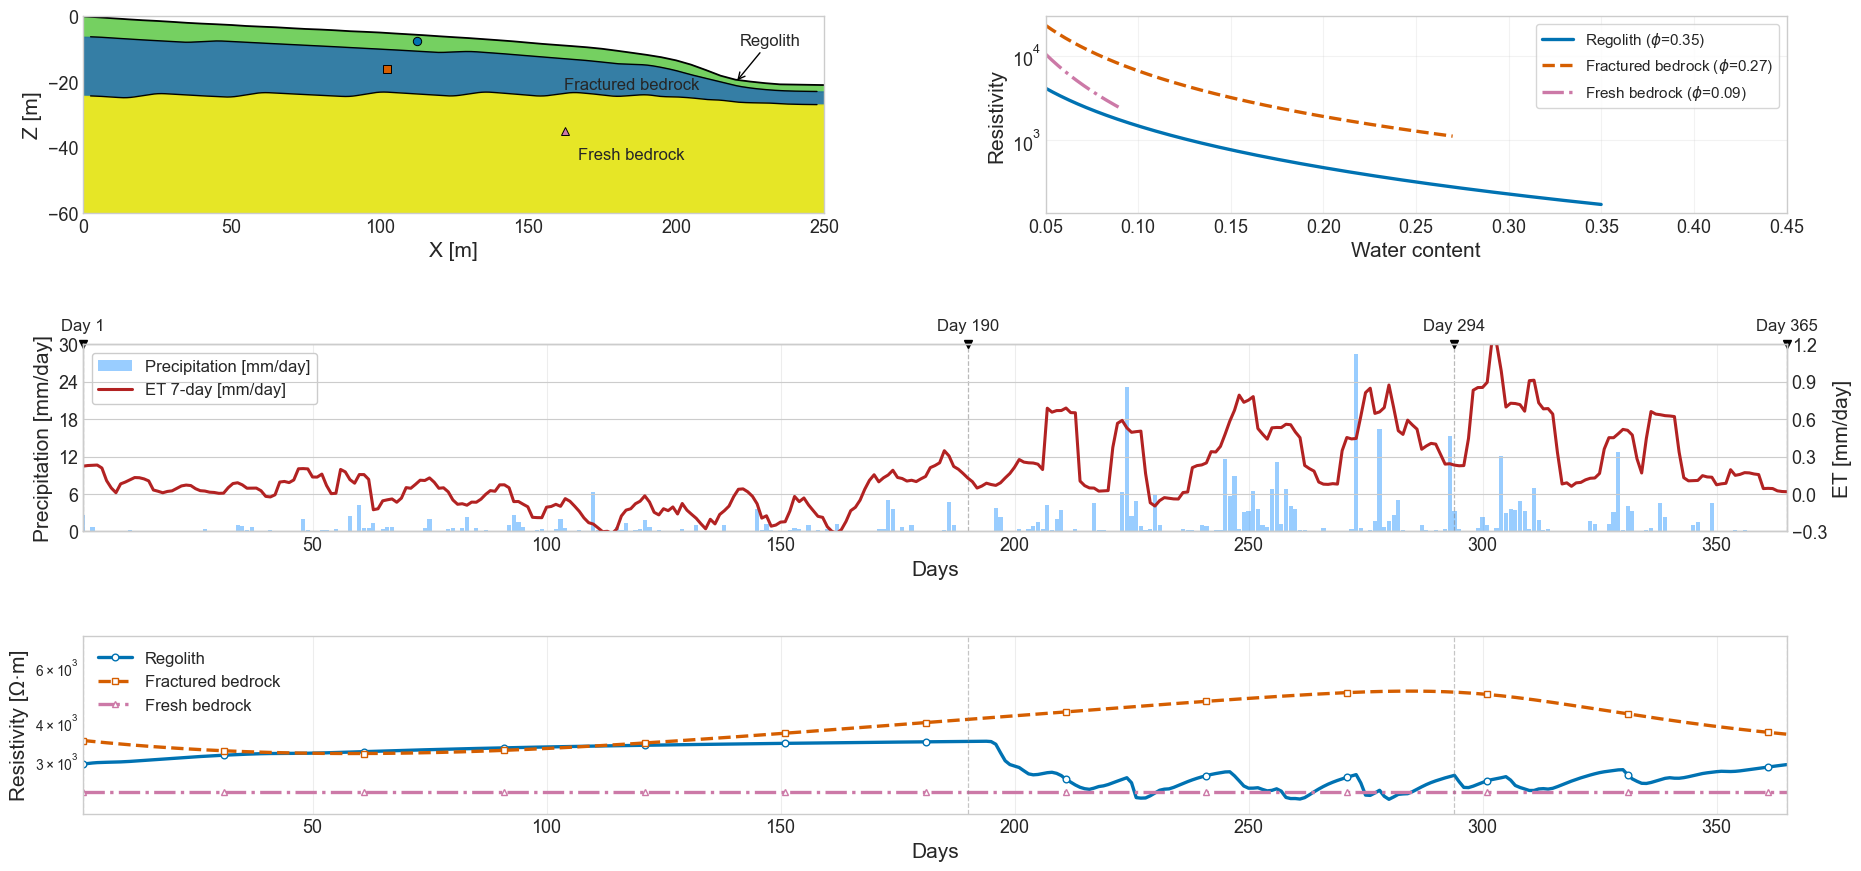

Saved Figure B: /home/luffy/deepertv1/resistivity_models_2d/figureB_rows2_3.png


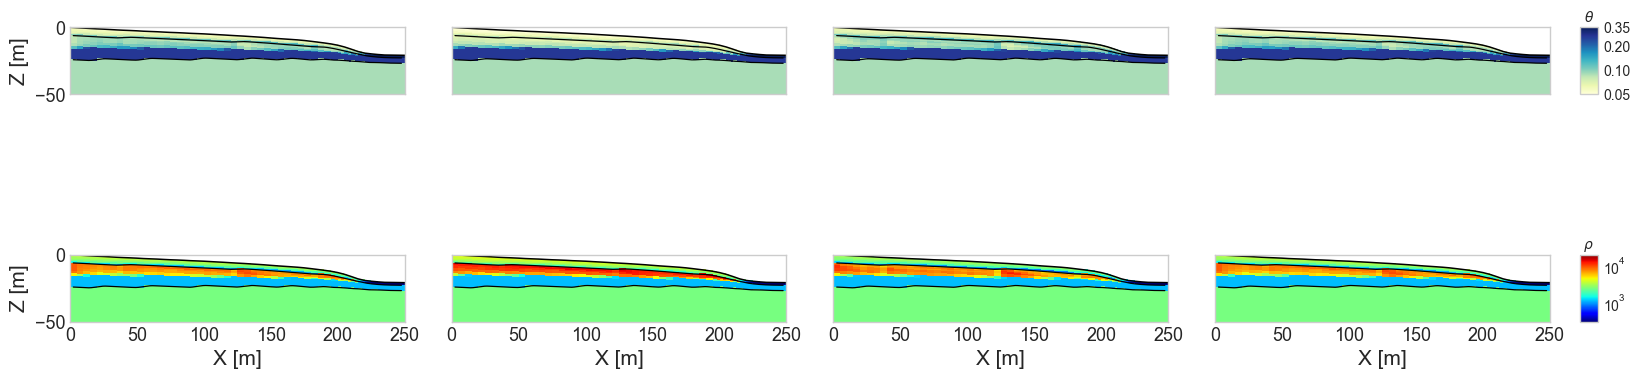

In [303]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import MaxNLocator, LogLocator, LogFormatterMathtext

from deepert.workflows.terrain import build_terrain_forward_case, parse_pftcl, read_slope_x

# ============================================================
# A) Global plotting controls and selected benchmark days
# ============================================================
selected_days = [1, 190, 294, 365]
y_index = 2

axis_label_fs = 15
tick_label_fs = 13

# ============================================================
# B) Resolve input/output folders (works from repo root or examples/)
# ============================================================
# Resolve paths if this cell is run independently
if 'project_root' not in globals() or 'parflow_dir' not in globals():
    here = Path.cwd().resolve()
    if (here / 'parflow_models').exists():
        project_root = here
    elif (here.parent / 'parflow_models').exists():
        project_root = here.parent
    else:
        raise FileNotFoundError('Cannot find parflow_models from current working directory.')
    parflow_dir = project_root / 'parflow_models'

resistivity_dir = project_root / 'resistivity_models_2d'
if not resistivity_dir.exists():
    raise FileNotFoundError(f'Resistivity directory not found: {resistivity_dir}')

# ============================================================
# C) Build terrain-following mesh coordinates used by all model subplots
#    - Xn, Zn: cell-node coordinates for pcolormesh
#    - Xc, Zc: cell-center coordinates for representative-point selection
# ============================================================
# Build physical terrain-following coordinates from ParFlow grid + slope
pftcl_path = parflow_dir / 'sc2d_6.out.pftcl'
slope_x_path = parflow_dir / 'sc2d_6.out.slope_x.pfb'
grid = parse_pftcl(pftcl_path)
slope_x = read_slope_x(slope_x_path, y_index=y_index)

rho_dummy = np.full((grid.nz, grid.nx), 100.0, dtype=float)
case_geom = build_terrain_forward_case(rho_dummy, grid, slope_x, y_index=y_index)

x_nodes = np.asarray(case_geom.x_nodes, dtype=float)                  # (nx+1,)
z_top = np.asarray(case_geom.z_top, dtype=float)                      # (nx+1,)
layer_thickness = np.asarray(case_geom.layer_thickness, dtype=float)  # top->bottom, (nz,)

z_offsets = np.concatenate(([0.0], -np.cumsum(layer_thickness)))

# pcolormesh node coordinates (nz+1, nx+1)
Xn = np.tile(x_nodes[None, :], (grid.nz + 1, 1))
Zn = z_top[None, :] + z_offsets[:, None]

# Cell-center x and edge-center z for plotting layer boundaries
x_centers = 0.5 * (x_nodes[:-1] + x_nodes[1:])
z_edge_centers = 0.5 * (Zn[:, :-1] + Zn[:, 1:])  # (nz+1, nx)

# Cell-center coordinates for selecting representative points
Xc = 0.25 * (Xn[:-1, :-1] + Xn[1:, :-1] + Xn[:-1, 1:] + Xn[1:, 1:])
Zc = 0.25 * (Zn[:-1, :-1] + Zn[1:, :-1] + Zn[:-1, 1:] + Zn[1:, 1:])

# ============================================================
# D) Load static hydro-geo fields
#    - porosity for theta conversion
#    - class map for layer boundaries and representative points
# ============================================================
# Porosity and class slices (ParFlow order: bottom->top)
porosity_3d = np.asarray(read_pfb(str(parflow_dir / 'sc2d_6.out.porosity.pfb')), dtype=float)
porosity_2d = porosity_3d[:, y_index, :]
phi_td = porosity_2d[::-1, :]

class_3d = np.asarray(read_pfb(str(parflow_dir / 'class.pfb')), dtype=int)
class_td = class_3d[:, y_index, :][::-1, :]  # top->bottom


# ============================================================
# E) Small helper utilities for boundaries, time indexing, and IO
# ============================================================
def _extract_two_layer_boundaries(class_top_down: np.ndarray, z_edges_center: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if class_top_down.shape != (grid.nz, grid.nx):
        raise ValueError(f'class slice shape {class_top_down.shape} != {(grid.nz, grid.nx)}')

    z12 = np.full(grid.nx, np.nan, dtype=float)
    z23 = np.full(grid.nx, np.nan, dtype=float)

    for ix in range(grid.nx):
        col = class_top_down[:, ix]
        transitions = np.where(col[:-1] != col[1:])[0]
        if transitions.size >= 1:
            edge_row = int(transitions[0] + 1)
            z12[ix] = z_edges_center[edge_row, ix]
        if transitions.size >= 2:
            edge_row = int(transitions[1] + 1)
            z23[ix] = z_edges_center[edge_row, ix]

    return z12, z23


def _smooth_boundary(x: np.ndarray, z: np.ndarray, *, upsample: int = 8, window: int = 17) -> tuple[np.ndarray, np.ndarray]:
    mask = np.isfinite(z)
    x_use = np.asarray(x[mask], dtype=float)
    z_use = np.asarray(z[mask], dtype=float)
    if x_use.size < 4:
        return x_use, z_use

    x_dense = np.linspace(float(x_use.min()), float(x_use.max()), int(max(64, x_use.size * upsample)))
    z_dense = np.interp(x_dense, x_use, z_use)

    window = int(max(3, window))
    if window % 2 == 0:
        window += 1
    if window >= z_dense.size:
        window = max(3, (z_dense.size // 2) * 2 - 1)

    if window >= 3:
        pad = window // 2
        kernel = np.ones(window, dtype=float) / float(window)
        z_pad = np.pad(z_dense, (pad, pad), mode='edge')
        z_dense = np.convolve(z_pad, kernel, mode='valid')

    return x_dense, z_dense


def _interp_boundary(x_query: np.ndarray, x_b: np.ndarray, z_b: np.ndarray) -> np.ndarray:
    if x_b.size < 2:
        return np.full_like(x_query, np.nan, dtype=float)
    return np.interp(x_query, x_b, z_b, left=float(z_b[0]), right=float(z_b[-1]))


z_if_12, z_if_23 = _extract_two_layer_boundaries(class_td, z_edge_centers)
x_if12, z_if12 = _smooth_boundary(x_centers, z_if_12)
x_if23, z_if23 = _smooth_boundary(x_centers, z_if_23)


def _day_to_step(day: int) -> int:
    return (int(day) - 1) * 24


def _load_sat_slice(step: int) -> np.ndarray:
    p = parflow_dir / f'sc2d_6.out.satur.{step:05d}.pfb'
    if not p.exists():
        raise FileNotFoundError(f'Missing saturation file: {p}')
    return np.asarray(read_pfb(str(p)), dtype=float)[:, y_index, :]


def _load_rho_slice(step: int) -> np.ndarray:
    p = resistivity_dir / f'resistivity2d_y2_t{step:05d}.npy'
    if not p.exists():
        raise FileNotFoundError(f'Missing resistivity file: {p}')
    return np.asarray(np.load(p), dtype=float)


def _to_top_down(values_bottom_up: np.ndarray) -> np.ndarray:
    arr = np.asarray(values_bottom_up, dtype=float)
    if arr.shape != (grid.nz, grid.nx):
        raise ValueError(f'Expected shape {(grid.nz, grid.nx)}, got {arr.shape}')
    return arr[::-1, :]


def _pick_representative_cell(class_top_down: np.ndarray, cid: int, x_cell: np.ndarray, z_cell: np.ndarray) -> tuple[int, int, float, float]:
    mask = class_top_down == int(cid)
    if not np.any(mask):
        raise ValueError(f'class {cid} not found in current slice')

    x_med = float(np.nanmedian(x_cell[mask]))
    z_med = float(np.nanmedian(z_cell[mask]))

    flat = np.flatnonzero(mask)
    x_vals = x_cell.ravel()[flat]
    z_vals = z_cell.ravel()[flat]
    dist2 = (x_vals - x_med) ** 2 + (z_vals - z_med) ** 2
    i_best = int(np.argmin(dist2))
    i_flat = int(flat[i_best])
    iz, ix = np.unravel_index(i_flat, class_top_down.shape)
    return int(iz), int(ix), float(x_cell[iz, ix]), float(z_cell[iz, ix])


# ============================================================
# F) Load snapshot fields for selected days (theta and resistivity)
# ============================================================
records = []
for day in selected_days:
    step = _day_to_step(day)
    sat_bu = _load_sat_slice(step)
    theta_bu = sat_bu * porosity_2d
    rho_bu = _load_rho_slice(step)
    records.append(
        {
            'day': int(day),
            'step': int(step),
            'theta_td': _to_top_down(theta_bu),
            'rho_td': _to_top_down(rho_bu),
        }
    )

print('Loaded models on physical mesh:')
for rec in records:
    print(
        f"  Day {rec['day']:>3d} (t={rec['step']:05d}) | "
        f"theta[min,max]=({np.nanmin(rec['theta_td']):.3f}, {np.nanmax(rec['theta_td']):.3f}) | "
        f"rho[min,max]=({np.nanmin(rec['rho_td']):.3f}, {np.nanmax(rec['rho_td']):.3f})"
    )

# ============================================================
# G) Choose one representative cell per layer and build full-year rho series
# ============================================================
# Representative points (one for each structural unit)
layer_meta = {
    # Colorblind-friendly palette + per-series style
    1: {'name': 'Regolith', 'color': '#0072B2', 'ls': '-',  'marker': 'o'},
    2: {'name': 'Fractured bedrock', 'color': '#D55E00', 'ls': '--', 'marker': 's'},
    3: {'name': 'Fresh bedrock', 'color': '#CC79A7', 'ls': '-.', 'marker': '^'},
}

rep_points = {}
for cid in [1, 2, 3]:
    iz, ix, xr, zr = _pick_representative_cell(class_td, cid, Xc, Zc)
    rep_points[cid] = {'iz': iz, 'ix': ix, 'x': xr, 'z': zr}

# Full-year resistivity time series at representative points
rho_series = {cid: np.full(int(n_days), np.nan, dtype=float) for cid in [1, 2, 3]}
for d in range(1, int(n_days) + 1):
    step = _day_to_step(d)
    rho_td = _to_top_down(_load_rho_slice(step))
    for cid in [1, 2, 3]:
        pt = rep_points[cid]
        rho_series[cid][d - 1] = float(rho_td[pt['iz'], pt['ix']])

print('Representative points (cell center):')
for cid in [1, 2, 3]:
    pt = rep_points[cid]
    print(f"  class {cid} {layer_meta[cid]['name']:<18s} -> x={pt['x']:.2f} m, z={pt['z']:.2f} m")

# ============================================================
# H) Petrophysical transformation parameters for top-right subplot
# ============================================================
# Petrophysical curve parameters (same as conversion script)
petro_params = {
    1: {'rho_sat': 170.0, 'rho_sat_s': 510.0, 'n': 2.2},
    2: {'rho_sat': 1100.0, 'rho_sat_s': None, 'n': 1.8},
    3: {'rho_sat': 2400.0, 'rho_sat_s': None, 'n': 2.5},
}

phi_by_class = {}
for cid in [1, 2, 3]:
    m = class_td == cid
    if not np.any(m):
        raise ValueError(f'class {cid} not found for phi extraction')
    phi_by_class[cid] = float(np.nanmedian(phi_td[m]))


def rho_from_theta(theta_vals: np.ndarray, *, rho_sat: float, n: float, phi: float, rho_sat_s: float | None, physical_theta_limit: bool = True) -> np.ndarray:
    theta_vals = np.asarray(theta_vals, dtype=float)
    s = theta_vals / float(phi)

    out = np.full(theta_vals.shape, np.nan, dtype=float)
    valid = s > 0.0
    if physical_theta_limit:
        valid = valid & (s <= 1.0)

    if not np.any(valid):
        return out

    sv = s[valid]
    sigma_sat = 1.0 / float(rho_sat)
    if rho_sat_s is None:
        sigma = sigma_sat * np.power(sv, float(n))
    else:
        sigma_sat_s = 1.0 / float(rho_sat_s)
        sigma_sat_p = sigma_sat - sigma_sat_s
        sigma = sigma_sat_p * np.power(sv, float(n)) + sigma_sat_s * np.power(sv, float(n) - 1.0)

    out[valid] = 1.0 / sigma
    return out


# ============================================================
# I) Color scaling shared by snapshot subplots
# ============================================================
# Fixed color limits (current style)
theta_vmin = 0.05
theta_vmax = 0.35

rho_vmin = 300
rho_vmax = 2e4

# Snapshot display domain (rows 2-3).
# Keep full domain by default; narrow xmax (e.g., 220.0) if you want visually taller equal-aspect panels.
# Snapshot display domain for row-2/3 panels (full model domain).
snapshot_xmin = float(x_nodes.min())
snapshot_xmax = float(x_nodes.max())

# Output directory for figures
figure_out_dir = project_root / 'resistivity_models_2d'
figure_out_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# J) Figure A: rows 1, 4, 5 together
#    - Top: structural model + petrophysical transformation
#    - Middle: rainfall + ET
#    - Bottom: representative-point resistivity time series
# ============================================================
fig_a = plt.figure(figsize=(18.5, 8.6), constrained_layout=True)
gs_a = fig_a.add_gridspec(3, 4, height_ratios=[1.0, 0.95, 0.9], wspace=0.08, hspace=0.20)

ax_struct = fig_a.add_subplot(gs_a[0, 0:2])
ax_petro = fig_a.add_subplot(gs_a[0, 2:4])
ax_ts = fig_a.add_subplot(gs_a[1, :])
ax_ts_r = ax_ts.twinx()
ax_rho_ts = fig_a.add_subplot(gs_a[2, :])

# ---- A1) Structural model (3 layers) ----
z12_nodes = _interp_boundary(x_nodes, x_if12, z_if12)
z23_nodes = _interp_boundary(x_nodes, x_if23, z_if23)
z_bottom = np.full_like(x_nodes, -60.0, dtype=float)

ax_struct.fill_between(x_nodes, z_top, z12_nodes, color='#6ece58', alpha=0.95)
ax_struct.fill_between(x_nodes, z12_nodes, z23_nodes, color='#2a77a0', alpha=0.95)
ax_struct.fill_between(x_nodes, z23_nodes, z_bottom, color='#e5e51a', alpha=0.95)
ax_struct.plot(x_nodes, z_top, color='k', lw=1.3)
ax_struct.plot(x_if12, z_if12, color='k', lw=1.0)
ax_struct.plot(x_if23, z_if23, color='k', lw=1.0)

x_label = float(x_nodes.min() + 0.74 * (x_nodes.max() - x_nodes.min()))
z_reg = 0.5 * (np.interp(x_label, x_nodes, z_top) + np.interp(x_label, x_nodes, z12_nodes))
z_frac = 0.5 * (np.interp(x_label, x_nodes, z12_nodes) + np.interp(x_label, x_nodes, z23_nodes))
z_fresh = 0.5 * (np.interp(x_label, x_nodes, z23_nodes) + (-60.0))

x_reg_ptr = float(x_nodes.min() + 0.88 * (x_nodes.max() - x_nodes.min()))
z_reg_ptr = 0.5 * (np.interp(x_reg_ptr, x_nodes, z_top) + np.interp(x_reg_ptr, x_nodes, z12_nodes))
ax_struct.annotate(
    'Regolith',
    xy=(x_reg_ptr, z_reg_ptr),
    xytext=(float(x_nodes.max() - 8.0), -5),
    fontsize=12,
    ha='right',
    va='top',
    arrowprops=dict(arrowstyle='->', lw=1.0, color='black'),
)
ax_struct.text(x_label, z_frac-1.5, 'Fractured bedrock', fontsize=12, ha='center', va='center')
ax_struct.text(x_label, z_fresh, 'Fresh bedrock', fontsize=12, ha='center', va='center')

ax_struct.set_xlim(float(x_nodes.min()), float(x_nodes.max()))
ax_struct.set_ylim([-60, 0])
ax_struct.set_xlabel('X [m]', fontsize=axis_label_fs)
ax_struct.set_ylabel('Z [m]', fontsize=axis_label_fs)
ax_struct.tick_params(axis='both', labelsize=tick_label_fs)
ax_struct.grid(False)

for cid in [1, 2, 3]:
    pt = rep_points[cid]
    ax_struct.plot(
        pt['x'],
        pt['z'],
        marker=layer_meta[cid]['marker'],
        ms=6.0,
        mfc=layer_meta[cid]['color'],
        mec='black',
        mew=0.7,
        ls='none',
        zorder=6,
    )

# ---- A2) Petrophysical transformation curves ----
theta = np.linspace(0.05, 0.45, 600)
for cid in [1, 2, 3]:
    prm = petro_params[cid]
    meta = layer_meta[cid]
    phi = phi_by_class[cid]
    rho_curve = rho_from_theta(
        theta,
        rho_sat=prm['rho_sat'],
        n=prm['n'],
        phi=phi,
        rho_sat_s=prm['rho_sat_s'],
        physical_theta_limit=True,
    )
    ax_petro.plot(theta, rho_curve, color=meta['color'], lw=2.4, ls=meta['ls'], label=f"{meta['name']} ($\phi$={phi:.2f})")

ax_petro.set_yscale('log')
ax_petro.set_xlim(0.05, 0.45)
ax_petro.set_xlabel('Water content', fontsize=axis_label_fs)
ax_petro.set_ylabel('Resistivity', fontsize=axis_label_fs)
ax_petro.tick_params(axis='both', labelsize=tick_label_fs)
ax_petro.yaxis.set_major_locator(LogLocator(base=10.0))
ax_petro.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
ax_petro.grid(True, which='major', alpha=0.25)
ax_petro.legend(loc='upper right', fontsize=11, frameon=True)


# ---- A3) Precipitation + ET ----
ax_ts.bar(days, rain_mm_day, color='dodgerblue', alpha=0.45, width=0.9, label='Precipitation [mm/day]')
ax_ts_r.plot(days, np.asarray(evap_7d, dtype=float), color='firebrick', lw=2.2, label='ET 7-day [mm/day]')

ax_ts.set_xlim(1, n_days)
ax_ts.set_xlabel('Days', fontsize=axis_label_fs)
ax_ts.set_ylabel('Precipitation [mm/day]', fontsize=axis_label_fs)
ax_ts_r.set_ylabel('ET [mm/day]', fontsize=axis_label_fs)

ax_ts.set_yticks([0, 6, 12, 18, 24, 30])
ax_ts.tick_params(axis='both', labelsize=tick_label_fs)
ax_ts_r.set_yticks([-0.3, 0.0, 0.3, 0.6, 0.9, 1.2])
ax_ts_r.tick_params(axis='both', labelsize=tick_label_fs)

for d in selected_days:
    ax_ts.axvline(d, color='gray', ls='--', lw=0.9, alpha=0.55, zorder=1)
    ax_ts.plot(d, 1.0, marker='v', markersize=6, color='black', transform=ax_ts.get_xaxis_transform(), clip_on=False)
    ax_ts.annotate(
        f'Day {d}',
        xy=(d, 1.0),
        xycoords=('data', 'axes fraction'),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=12,
    )

# Draw grid beneath data and legend.
ax_ts.set_axisbelow(True)
ax_ts.grid(True, axis='both', alpha=0.35, zorder=0)

h1, l1 = ax_ts.get_legend_handles_labels()
h2, l2 = ax_ts_r.get_legend_handles_labels()
leg_ts = ax_ts.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=12, frameon=True, framealpha=1.0)
leg_ts.get_frame().set_facecolor('white')
leg_ts.get_frame().set_edgecolor('0.8')
leg_ts.set_zorder(20)
ax_ts.set_ylim([0,30])
ax_ts_r.set_ylim([-0.3,1.2])

# ---- A4) Resistivity time series at representative points ----
for cid in [1, 2, 3]:
    name = layer_meta[cid]['name']
    meta = layer_meta[cid]
    ax_rho_ts.plot(
        days,
        rho_series[cid],
        color=meta['color'],
        lw=2.4,
        ls=meta['ls'],
        marker=meta['marker'],
        markevery=30,
        ms=4.8,
        mfc='white',
        mew=1.0,
        label=name,
    )

for d in selected_days:
    ax_rho_ts.axvline(d, color='gray', ls='--', lw=0.9, alpha=0.45)

ax_rho_ts.set_xlim(1, n_days)
ax_rho_ts.set_yscale('log')
ax_rho_ts.set_xlabel('Days', fontsize=axis_label_fs)
ax_rho_ts.set_ylabel('Resistivity [Ω·m]', fontsize=axis_label_fs)
ax_rho_ts.tick_params(axis='both', labelsize=tick_label_fs)
ax_rho_ts.grid(True, which='major', axis='both', alpha=0.35)
rho_vals = []
for cid in [1, 2, 3]:
    vv = np.asarray(rho_series[cid], dtype=float)
    vv = vv[np.isfinite(vv) & (vv > 0.0)]
    if vv.size:
        rho_vals.append(vv)
if rho_vals:
    vv_all = np.concatenate(rho_vals)
    y_min = float(np.nanmin(vv_all))
    y_max = float(np.nanmax(vv_all))
    ax_rho_ts.set_ylim(y_min * 0.90, y_max * 1.50)
ax_rho_ts.legend(loc='upper left', fontsize=12)

fig_a_path = figure_out_dir / 'figureA_rows1_4_5.png'
fig_a.savefig(fig_a_path, dpi=600, bbox_inches='tight')
print(f'Saved Figure A: {fig_a_path}')
plt.show()

# ============================================================
# J2) Figure B: rows 2 and 3 together (4 selected days)
#    - Top row: moisture snapshots
#    - Bottom row: resistivity snapshots
# ============================================================
fig_b = plt.figure(figsize=(18.5, 5.0), constrained_layout=False)
# Reserve larger right margin for colorbars + labels (prevents label-panel overlap)
gs_b = fig_b.add_gridspec(2, 4, left=0.06, right=0.86, bottom=0.11, top=0.95, wspace=0.14, hspace=0.18)

axes_theta = [fig_b.add_subplot(gs_b[0, j]) for j in range(4)]
axes_rho = [fig_b.add_subplot(gs_b[1, j]) for j in range(4)]

qm_theta = None
qm_rho = None
for j, rec in enumerate(records):
    ax_t = axes_theta[j]
    qm_theta = ax_t.pcolormesh(
        Xn,
        Zn,
        rec['theta_td'],
        shading='flat',
        cmap='YlGnBu',
        norm=LogNorm(vmin=theta_vmin, vmax=theta_vmax),
        edgecolors='none',
        linewidth=0.0,
    )
    ax_t.plot(x_if12, z_if12, color='k', lw=0.9)
    ax_t.plot(x_if23, z_if23, color='k', lw=0.9)
    ax_t.plot(x_nodes, z_top, color='k', lw=1.1)

    if j == 0:
        ax_t.set_ylabel('Z [m]', fontsize=axis_label_fs)
    else:
        ax_t.tick_params(labelleft=False)
    ax_t.tick_params(labelbottom=False)

    ax_r = axes_rho[j]
    qm_rho = ax_r.pcolormesh(
        Xn,
        Zn,
        rec['rho_td'],
        shading='flat',
        cmap='jet',
        norm=LogNorm(vmin=rho_vmin, vmax=rho_vmax),
        edgecolors='none',
        linewidth=0.0,
    )
    ax_r.plot(x_if12, z_if12, color='k', lw=0.9)
    ax_r.plot(x_if23, z_if23, color='k', lw=0.9)
    ax_r.plot(x_nodes, z_top, color='k', lw=1.1)

    ax_r.set_xlabel('X [m]', fontsize=axis_label_fs)
    if j == 0:
        ax_r.set_ylabel('Z [m]', fontsize=axis_label_fs)
    else:
        ax_r.tick_params(labelleft=False)

for ax in axes_theta:
    ax.tick_params(axis='both', labelsize=tick_label_fs)
    ax.set_xlim(snapshot_xmin, snapshot_xmax)
    ax.set_ylim(float(np.nanmin(Zn)), float(np.nanmax(Zn)))
    ax.set_aspect('equal', adjustable='box', anchor='C')
    ax.set_ylim([-50, 0])
    ax.grid(False)

for ax in axes_rho:
    ax.tick_params(axis='both', labelsize=tick_label_fs)
    ax.set_xlim(snapshot_xmin, snapshot_xmax)
    ax.set_ylim(float(np.nanmin(Zn)), float(np.nanmax(Zn)))
    ax.set_aspect('equal', adjustable='box', anchor='C')
    ax.set_ylim([-50, 0])
    ax.grid(False)

# Colorbars: same height as corresponding row, placed just outside rightmost panel
fig_b.canvas.draw()
row2_bbox = axes_theta[-1].get_position()
row3_bbox = axes_rho[-1].get_position()
cb_gap = 0.016
cb_width = 0.01
cb_x0 = row2_bbox.x1 + cb_gap

cax1 = fig_b.add_axes([cb_x0, row2_bbox.y0, cb_width, row2_bbox.height])
cbar1 = fig_b.colorbar(qm_theta, cax=cax1)
cbar1.ax.tick_params(labelsize=10)
cbar1.set_label('')
cbar1.ax.set_title(r'$\it{\theta}$', fontsize=10, pad=4)
theta_ticks = [0.05, 0.10, 0.20, 0.35]
theta_ticks = [t for t in theta_ticks if theta_vmin <= t <= theta_vmax]
cbar1.set_ticks(theta_ticks)
cbar1.set_ticklabels([f'{t:.2f}' for t in theta_ticks])
cbar1.ax.minorticks_off()
cbar1.ax.yaxis.tick_right()

cax2 = fig_b.add_axes([cb_x0, row3_bbox.y0, cb_width, row3_bbox.height])
cbar2 = fig_b.colorbar(qm_rho, cax=cax2)
cbar2.ax.tick_params(labelsize=10)
cbar2.set_label('')
cbar2.ax.set_title(r'$\it{\rho}$', fontsize=10, pad=4, fontweight='bold')
cbar2.ax.yaxis.tick_right()

fig_b_path = figure_out_dir / 'figureB_rows2_3.png'
fig_b.savefig(fig_b_path, dpi=600, bbox_inches='tight')
print(f'Saved Figure B: {fig_b_path}')
plt.show()
